In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [55]:
import seaborn as sns

In [3]:
df_DE = df[df["job_title_short"]=="Data Engineer"].copy()

In [4]:
mean_salary = df_DE["salary_year_avg"].mean()
median_salary = df_DE["salary_year_avg"].median()

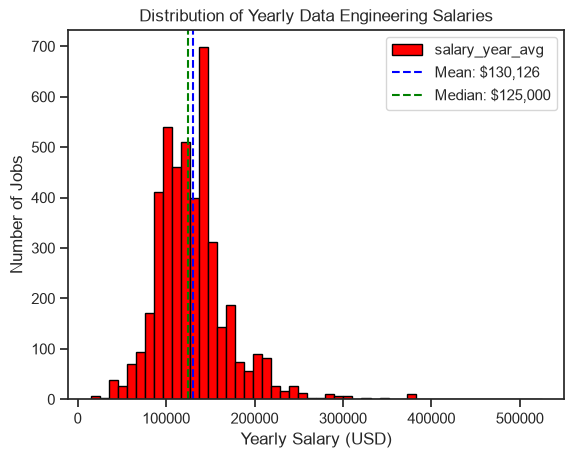

In [62]:
df_DE["salary_year_avg"].plot(kind="hist",bins=50,color="red",edgecolor="black")
plt.axvline(mean_salary,color="blue",linestyle="dashed",label=f"Mean: ${mean_salary:,.0f}")
plt.axvline(median_salary,color="green",linestyle="dashed",label=f"Median: ${median_salary:,.0f}")
plt.xlabel("Yearly Salary (USD)")
plt.ylabel("Number of Jobs")
plt.title("Distribution of Yearly Data Engineering Salaries")
plt.legend()
plt.show()

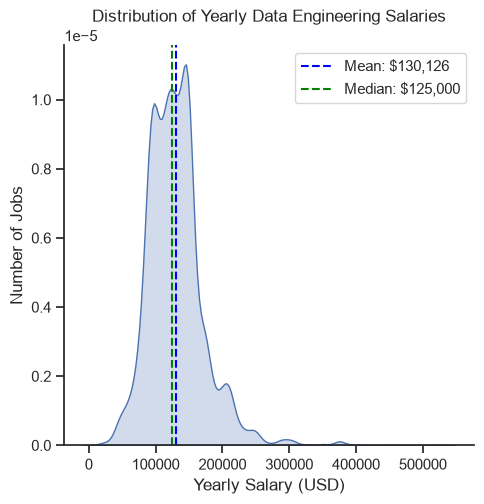

In [61]:
#df_DE["salary_year_avg"].plot(kind="hist",bins=50,color="red",edgecolor="black")
sns.displot(df_DE["salary_year_avg"],kind="kde",fill=True)
sns.set_theme(style="ticks")
plt.axvline(mean_salary,color="blue",linestyle="dashed",label=f"Mean: ${mean_salary:,.0f}")
plt.axvline(median_salary,color="green",linestyle="dashed",label=f"Median: ${median_salary:,.0f}")
plt.xlabel("Yearly Salary (USD)")
plt.ylabel("Number of Jobs")
plt.title("Distribution of Yearly Data Engineering Salaries")
plt.legend()
plt.show()

In [8]:
df_DE_Ger = df[(df["job_title_short"]=="Data Engineer") & (df["job_country"]=="Germany")].copy()

In [10]:
df_DE_Ger.dropna(subset=["salary_year_avg"],inplace=True)

In [14]:
df_DE_Ger_expl = df_DE_Ger.explode("job_skills")

In [18]:
df_DE_Ger_expl = df_DE_Ger_expl.groupby("job_skills")["salary_year_avg"].agg(["count","median"])

In [29]:
df_DE_Ger_toppay = df_DE_Ger_expl.sort_values(by="median",ascending=False).head(10)

df_DE_Ger_skills = df_DE_Ger_expl.sort_values(by="count",ascending=False).head(10).sort_values(by="median",ascending=False)


In [47]:
df_DE_Ger_skills

,count,median
job_skills,,
spark,19,147500.0
sql,19,147500.0
terraform,5,147500.0
aws,10,143750.0
python,20,128587.5
airflow,8,122891.5
gcp,6,122891.5
git,6,122472.0
azure,8,98301.5


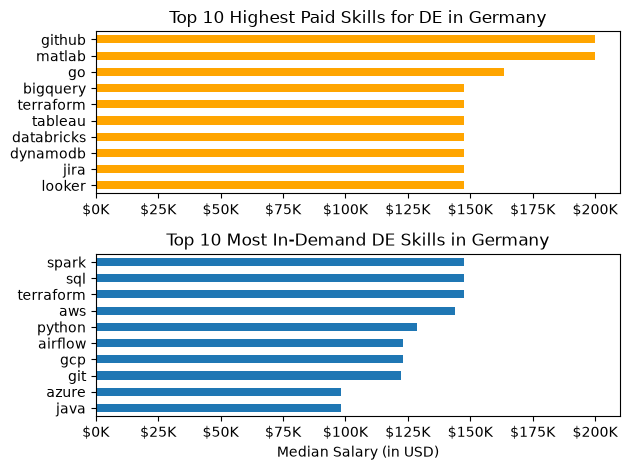

In [37]:
fig,ax = plt.subplots(2,1)

df_DE_Ger_toppay.plot(kind="barh",y="median",ax=ax[0],color="orange",legend=False)
df_DE_Ger_skills.plot(kind="barh",y="median",ax=ax[1],legend=False)

ax[0].invert_yaxis()
ax[0].set_title("Top 10 Highest Paid Skills for DE in Germany")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"${int(x/1000)}K"))

ax[1].invert_yaxis()
ax[1].set_title("Top 10 Most In-Demand DE Skills in Germany")
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary (in USD)")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"${int(x/1000)}K"))

fig.tight_layout()


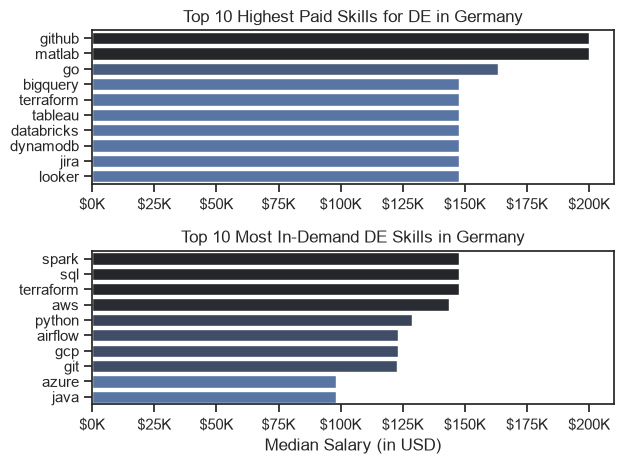

In [54]:
fig,ax = plt.subplots(2,1)

#df_DE_Ger_toppay.plot(kind="barh",y="median",ax=ax[0],color="orange",legend=False)
#df_DE_Ger_skills.plot(kind="barh",y="median",ax=ax[1],legend=False)
sns.barplot(data=df_DE_Ger_toppay,x="median",y=df_DE_Ger_toppay.index,ax=ax[0],hue="median",palette="dark:b_r",legend=False)
sns.barplot(data=df_DE_Ger_skills,x="median",y=df_DE_Ger_skills.index,ax=ax[1],hue="median",palette="dark:b_r",legend=False)

sns.set_theme(style="ticks")

#ax[0].invert_yaxis()
ax[0].set_title("Top 10 Highest Paid Skills for DE in Germany")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"${int(x/1000)}K"))

#ax[1].invert_yaxis()
ax[1].set_title("Top 10 Most In-Demand DE Skills in Germany")
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary (in USD)")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"${int(x/1000)}K"))

fig.tight_layout()


In [63]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
india_jobs = df[(df['job_country'] == 'India') & (df['job_title_short'].isin(job_titles))]

In [64]:
india_jobs = india_jobs.dropna(subset=['salary_year_avg'])

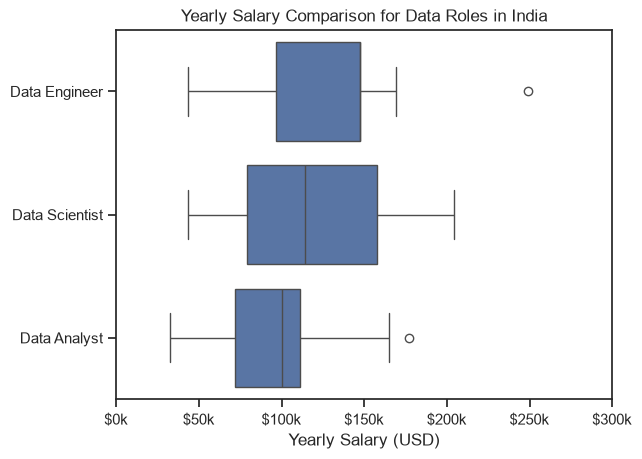

In [65]:
sns.boxplot(data=india_jobs, x='salary_year_avg', y='job_title_short')
plt.title('Yearly Salary Comparison for Data Roles in India')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 300000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.show()

In [66]:
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])

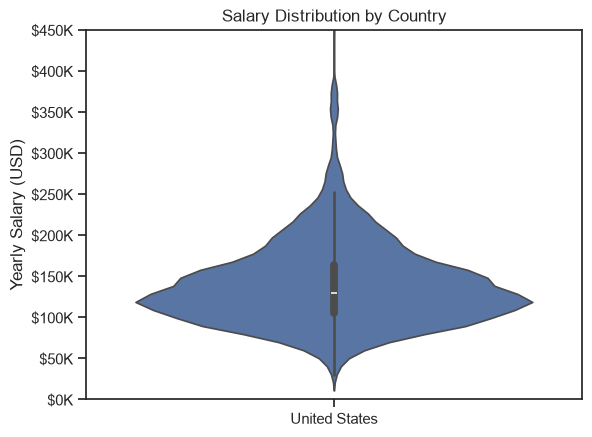

In [67]:
sns.violinplot(x='job_country', y='salary_year_avg', data=df_DS_US)
plt.title('Salary Distribution by Country')
plt.xlabel('')
plt.ylabel('Yearly Salary (USD)')
plt.ylim(0, 450000)  
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()